In [ ]:
# 1 - data cleaning

# The purpose of this notebook is to try downsampling the data to see if that improves the model
# our model is now trained only on standards

# based on the above results, (64, 64) downsampling had the best performance, the current best model
# is at the end of this notebook

In [6]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import sys
import os
import importlib
import numpy as np

sys.path.append(os.path.abspath(".."))
from src.data import load_images_from_metadata, filter_images

In [7]:
# load all of the data into metadata csv file including the new data (data_new_2))
from src.build_metadata import load_metadata
import importlib
import src.build_metadata as build_metadata

importlib.reload(build_metadata)
build_metadata.load_metadata(
    data_base_dir="../data",
    new_data_base_dir="../data_new",
    new_data_2_base_dir="../data_new_2",
    output_file="metadata.csv",
)

Applied human ratings to 851 DD rows.
Saved metadata to ../data\metadata.csv
Combined records: 1345


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (1...
1,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (2...
2,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (3...
3,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (4...
4,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (5...
...,...,...,...,...,...,...,...,...
1340,5.8,Brooke,7.21.26,TEST,2BDR-9F02,25-143,flat,../data_test\{leveling-5.8}_P{Brooke}_D{7.21.2...
1341,6.3,Brooke,7.21.26,TEST,2BDR-9F02,25-141,flat,../data_test\{leveling-6.3}_P{Brooke}_D{7.21.2...
1342,6.8,Brooke,7.21.26,TEST,2BDR-9F02,25-104,flat,../data_test\{leveling-6.8}_P{Brooke}_D{7.21.2...
1343,8.0,Brooke,7.21.26,TEST,2BDR-9F02,25-125,flat,../data_test\{leveling-8.0}_P{Brooke}_D{7.21.2...


In [8]:
# get the data
data = load_images_from_metadata("../data/metadata.csv", crop_fraction = .4, use_cv2=True)

data_standards = filter_images(data, ImageType = "STD", State = "flat", DateCollected = ["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"])
data_real_paint = filter_images(data, ImageType = "DD", State = "flat")

Loaded 1345 images (cropping=ON, backend=cv2)
Filtered down to 177 images
Filtered down to 430 images


In [ ]:
# apply downsampling to data_standards and data_real_paint

In [ ]:
# first try (64,64) downsampling

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 1.5993
Epoch 4/10 - Loss: 3.2054
Epoch 6/10 - Loss: 1.9385
Epoch 8/10 - Loss: 4.5479
Epoch 10/10 - Loss: 1.1842

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.086203*Prediction^2 + -0.073869*Prediction + 1.964173

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.667
Within ±1: 78.8%
Within ±2: 97.0%
Within ±3: 99.5%
Within ±4: 100.0%


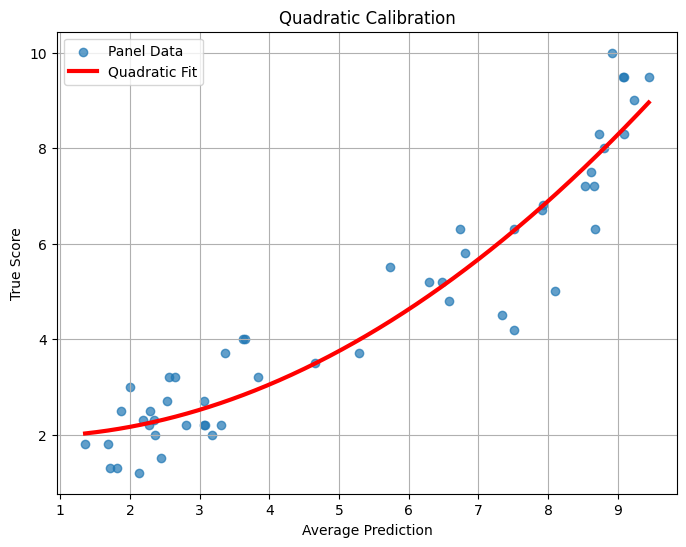

PanelID  AvgPrediction  PredictionStd  TrueScore  N
 25-133       7.338823       0.845228        4.5  6
 25-113       1.864085       0.716663        2.5  6
 25-115       6.482245       0.707912        5.2 12
 25-145       7.513264       0.707369        4.2 12
 25-132       7.916840       0.678218        6.7 11
 25-126       2.528191       0.612619        2.7  6
 25-144       6.289863       0.602570        5.2 12
 25-110       3.625824       0.567465        4.0 12
 25-116       5.291667       0.546769        3.7  6
 25-150       8.107303       0.533294        5.0  6
 25-119       3.653702       0.506209        4.0  6
 25-101       3.075001       0.495384        2.2 11
 25-143       6.815525       0.493848        5.8  6
 25-136       6.739743       0.491167        6.3 12
 25-142       3.842960       0.408533        3.2 12
 25-109       2.188287       0.373960        2.3  6
 25-131       5.734819       0.366801        5.5  6
 25-120       2.562217       0.359755        3.2 12
 25-141     

: 

In [ ]:
# current best model (trained only on standards), need to train for ideal epochs eventually

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (64,64)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

In [ ]:
# try (128,128) downsampling - this is what we were originally doing

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 0.3335
Epoch 4/10 - Loss: 3.5746
Epoch 6/10 - Loss: 1.3886
Epoch 8/10 - Loss: 0.1066
Epoch 10/10 - Loss: 1.7944

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.195752*Prediction^2 + -1.556669*Prediction + 5.131583

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.720
Within ±1: 74.4%
Within ±2: 97.0%
Within ±3: 99.8%
Within ±4: 100.0%


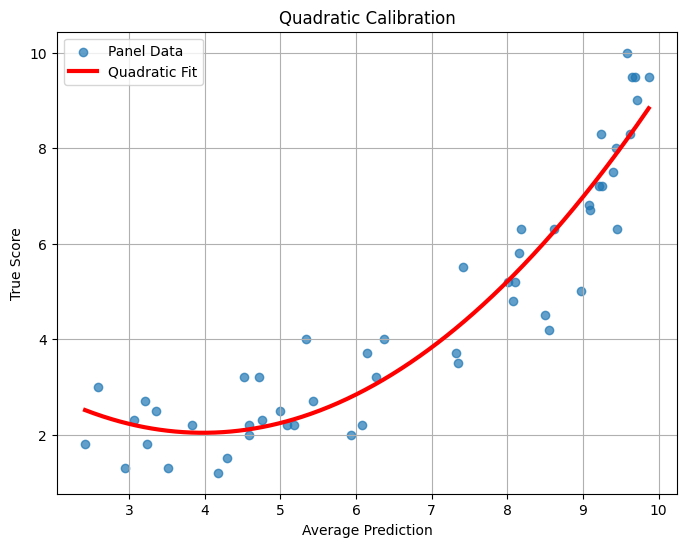

PanelID  AvgPrediction  PredictionStd  TrueScore  N
 25-108       4.175117       1.403581        1.2 12
 25-113       3.349766       1.298486        2.5  6
 25-111       3.516793       1.155526        1.3 12
 25-110       5.344626       1.120167        4.0 12
 25-100       3.825433       1.090954        2.2 19
 25-101       5.174026       0.798395        2.2 11
 25-126       3.207134       0.797691        2.7  6
 25-129       4.580567       0.624240        2.2  6
 25-138       5.429826       0.612036        2.7  6
 25-120       4.722180       0.587524        3.2 12
 25-109       3.064131       0.572660        2.3  6
 25-133       8.504550       0.524015        4.5  6
 25-114       4.293952       0.492220        1.5  6
 25-130       2.939134       0.471451        1.3  6
 25-115       8.098724       0.446471        5.2 12
 25-137       4.512509       0.445660        3.2  6
 25-150       8.974543       0.408863        5.0  6
 25-122       4.753184       0.383642        2.3  6
 25-102     

In [7]:
# current best model (trained only on standards)

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (128,128)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 3.7541
Epoch 4/10 - Loss: 5.0219
Epoch 6/10 - Loss: 5.2238
Epoch 8/10 - Loss: 1.3003
Epoch 10/10 - Loss: 1.6715

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.130953*Prediction^2 + 0.145001*Prediction + 1.773129

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.858
Within ±1: 68.6%
Within ±2: 90.0%
Within ±3: 97.9%
Within ±4: 99.8%


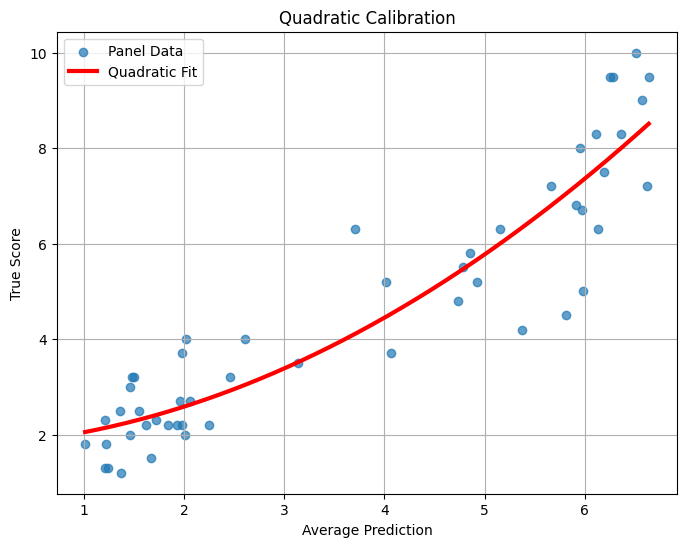

PanelID  AvgPrediction  PredictionStd  TrueScore  N
 25-136       3.700955       0.750557        6.3 12
 25-145       5.378624       0.719800        4.2 12
 25-133       5.809982       0.663443        4.5  6
 25-115       4.921911       0.613889        5.2 12
 25-144       4.014574       0.613760        5.2 12
 25-126       1.959488       0.536411        2.7  6
 25-150       5.983992       0.533975        5.0  6
 25-132       5.975035       0.532993        6.7 11
 25-110       2.606565       0.532382        4.0 12
 25-113       1.358735       0.501489        2.5  6
 25-128       6.623131       0.475012        7.2 12
 25-143       4.856447       0.469157        5.8  6
 25-135       6.571680       0.462737        9.0 12
 25-140       4.739705       0.456457        4.8  6
 25-107       5.660592       0.450363        7.2 12
 25-147       6.116593       0.432300        8.3 12
 25-101       1.980796       0.431968        2.2 11
 25-146       6.131088       0.430125        6.3  7
 25-125     

In [10]:
# try (32,32) downsampling - this is what we were originally doing

# current best model (trained only on standards)

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (32,32)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

In [ ]:
# try (48,48) downsampling 

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 2.6030
Epoch 4/10 - Loss: 4.7764
Epoch 6/10 - Loss: 5.5784
Epoch 8/10 - Loss: 4.7718
Epoch 10/10 - Loss: 0.4198

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.149329*Prediction^2 + -1.424540*Prediction + 5.208411

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.925
Within ±1: 62.1%
Within ±2: 89.8%
Within ±3: 98.6%
Within ±4: 100.0%


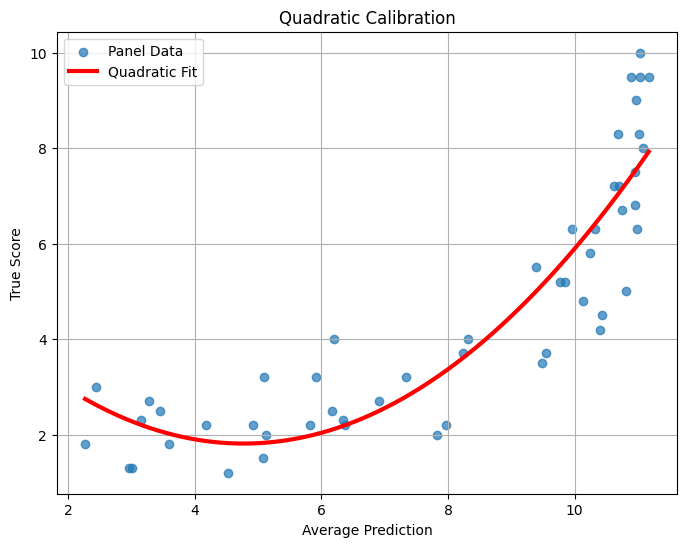

PanelID  AvgPrediction  PredictionStd  TrueScore  N
 25-108       4.524623       1.823107        1.2 12
 25-120       5.085533       1.610049        3.2 12
 25-113       3.457374       1.582143        2.5  6
 25-100       4.171432       1.518666        2.2 19
 25-137       5.916874       1.496826        3.2  6
 25-110       6.196387       1.416482        4.0 12
 25-129       4.919820       1.101920        2.2  6
 25-101       5.820346       1.101210        2.2 11
 25-103       6.167563       0.954486        2.5  5
 25-126       3.270181       0.848752        2.7  6
 25-138       6.902693       0.823781        2.7  6
 25-114       5.075081       0.789349        1.5  6
 25-142       7.342272       0.788257        3.2 12
 25-109       3.152571       0.760640        2.3  6
 25-111       3.006290       0.737888        1.3 12
 25-139       5.119522       0.721119        2.0  6
 25-122       6.337393       0.692645        2.3  6
 25-140      10.136327       0.670292        4.8  6
 25-119     

In [ ]:

# current best model (trained only on standards)

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (48,48)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 2.3101
Epoch 4/10 - Loss: 0.6053
Epoch 6/10 - Loss: 0.4366
Epoch 8/10 - Loss: 0.5462
Epoch 10/10 - Loss: 0.6261

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.055673*Prediction^2 + -0.650832*Prediction + 3.931996

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.751
Within ±1: 72.3%
Within ±2: 95.8%
Within ±3: 99.3%
Within ±4: 100.0%


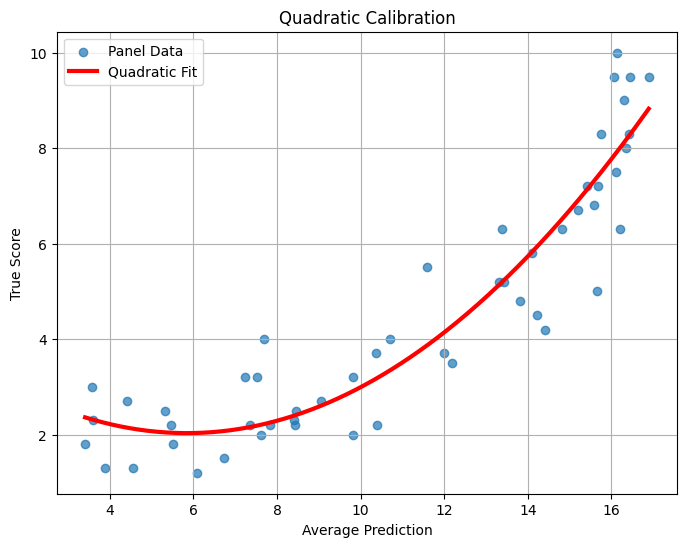

PanelID  AvgPrediction  PredictionStd  TrueScore  N
 25-108       6.085502       2.972600        1.2 12
 25-113       5.319766       2.116233        2.5  6
 25-110       7.685273       1.883717        4.0 12
 25-100       5.467025       1.857464        2.2 19
 25-120       7.245312       1.701360        3.2 12
 25-111       4.553873       1.503522        1.3 12
 25-126       4.417879       1.454773        2.7  6
 25-101       7.840607       1.175329        2.2 11
 25-150      15.651826       0.776927        5.0  6
 25-115      13.439162       0.736583        5.2 12
 25-142       9.810669       0.689783        3.2 12
 25-137       7.534386       0.672474        3.2  6
 25-133      14.228215       0.661505        4.5  6
 25-129       7.366056       0.661343        2.2  6
 25-131      11.579826       0.651839        5.5  6
 25-116      11.986354       0.644675        3.7  6
 25-103       8.464881       0.622995        2.5  5
 25-107      15.668641       0.622874        7.2 12
 25-144     

In [3]:
# (92, 92)


# current best model (trained only on standards)

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (92,92)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

In [ ]:
#
# insight: based on the above results, (64, 64) downsampling had the best performance
#

In [ ]:

# current best model (trained only on standards) with (64,64) downsampling, need to train for the ideal epochs eventually 

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

IMG_SIZE = (92,92)    # change here

X_train_list, y_train, _ = prepare_data_with_groups(
    data_standards,
    img_size=IMG_SIZE
)

X_test_list, y_test, groups_test = prepare_data_with_groups(
    data_real_paint,
    img_size=IMG_SIZE
)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(
        IMG_SIZE[0],
        scale=(0.95, 1.0)
    ),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))